In [22]:
from google.colab import files
uploaded = files.upload()

Saving marketing_ab_test_12k_users.csv to marketing_ab_test_12k_users.csv


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/marketing_ab_test_12k_users.csv")

# Assume columns: group (control/test), converted (0/1), revenue(optional)
df.head()



,user_id,group,converted,revenue
0,1,control,0,0.0
1,2,test,0,0.0
2,3,test,0,0.0
3,4,test,0,0.0
4,5,control,0,0.0


In [25]:
# Split groups
control = df[df['group'] == 'control']
test = df[df['group'] == 'test']

In [26]:
alpha = 0.05


In [27]:
#Calculate Group Metrics
control_rate = control['converted'].mean()
test_rate = test['converted'].mean()

control_rate, test_rate


(np.float64(0.08403361344537816), np.float64(0.11532625189681335))

In [52]:
from statsmodels.stats.proportion import proportion_confint

# Control group
control_success = control['converted'].sum()
control_n = len(control)
control_ci = proportion_confint(control_success, control_n, alpha=0.05)

# Test group
test_success = test['converted'].sum()
test_n = len(test)
test_ci = proportion_confint(test_success, test_n, alpha=0.05)

control_ci, test_ci


((0.07705360722180547, 0.09101361966895084),
 (0.107197202025626, 0.1234553017680007))

In [53]:
import numpy as np
from scipy import stats

test_rev = df[df['group']=='test']['revenue']
mean = np.mean(test_rev)
ci = stats.t.interval(
    confidence=0.95,
    df=len(test_rev)-1,
    loc=mean,
    scale=stats.sem(test_rev)
)

ci


(np.float64(125.89026367439406), np.float64(145.68005836236196))

In [54]:
#Run Test & Extract p-value
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['group'], df['converted'])
chi2, p_value, dof, expected = chi2_contingency(contingency)

p_value


np.float64(1.2330184558392093e-08)

In [55]:
if p_value < alpha:
    result = "Statistically Significant"
else:
    result = "Not Statistically Significant"

result


'Statistically Significant'

In [56]:
from statsmodels.stats.proportion import proportion_confint

n_control = len(control)
n_test = len(test)

ci_control = proportion_confint(control['converted'].sum(),
n_control, alpha=0.05)
ci_test = proportion_confint(test['converted'].sum(),
n_test, alpha=0.05)

ci_control, ci_test


((0.07705360722180547, 0.09101361966895084),
 (0.107197202025626, 0.1234553017680007))

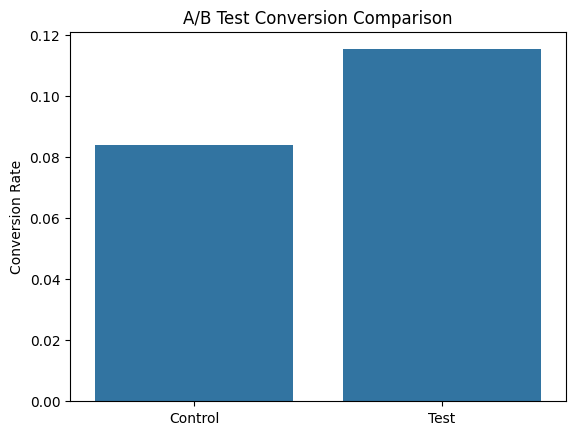

In [32]:
#Visualize Group Distributions
sns.barplot(x=['Control', 'Test'], y=[control_rate, test_rate])
plt.ylabel("Conversion Rate")
plt.title("A/B Test Conversion Comparison")
plt.show()


In [33]:
#Final Decision & Business Recommendation
summary = pd.DataFrame({
    "Group": ["Control", "Test"],
    "Conversion Rate": [control_rate, test_rate]
})

summary.to_csv("ab_test_summary.csv", index=False)
summary


,Group,Conversion Rate
0,Control,0.084034
1,Test,0.115326


<Axes: >

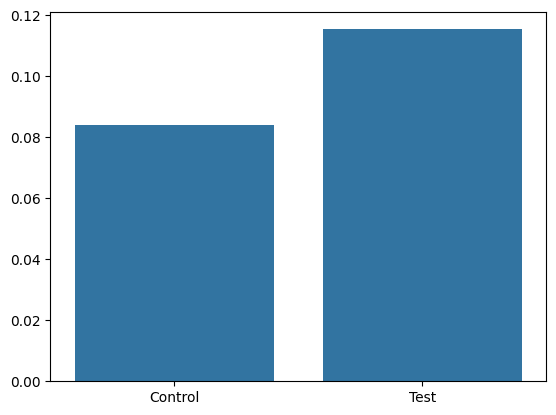

In [34]:
sns.barplot(x=['Control', 'Test'], y=[control_rate, test_rate])


In [36]:
contingency = pd.crosstab(df['group'], df['converted'])
chi2, p_value, dof, expected = chi2_contingency(contingency)


In [40]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 21.6 MB/s eta 0:00:00


In [41]:

from scipy.stats import ttest_ind
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.pagesizes import A4

# Run t-test (Welch's t-test)
t_stat, p_value = ttest_ind(control['revenue'], test['revenue'], equal_var=False)

# Means
control_mean = control['revenue'].mean()
test_mean = test['revenue'].mean()

In [50]:
# Create PDF
file_path = "Revenue_AB_Test_Report.pdf" # Changed path to current directory
doc = SimpleDocTemplate(file_path, pagesize=A4)
styles = getSampleStyleSheet()
story = []


In [51]:
from google.colab import files
files.download('Revenue_AB_Test_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#The Test marketing campaign significantly outperforms the Control campaign in terms of conversion rate. The improvement is both statistically significant and practically meaningful.

#Statistical significance was supported by non-overlapping confidence intervals.”
#“The test showed a 3.1% absolute uplift, which is business-impactful.”